<a href="https://colab.research.google.com/github/vaishalidesai1/marie-minesweeper-simulator/blob/main/buscaminas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import os
from google.colab import files
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display as ipy_display
import io
import urllib.request

FILAS        = 16
COLUMNAS     = 16
MINAS        = 10
MINA_VAL     = -1
TABLERO_BASE = 0x400

NL_HEX = '00A'   # salto de linea UTF-16BE

# Mensajes de output Unicode
MENSAJES_OUTPUT = {
    'Fila':   'Fila:   ',
    'Col':    'Col:    ',
    'Acc':    'Acc:    ',
    'Band':   'NoBand! ',
    'Mov':    'Movs: ',
    'Gana':   'Ganaste!',
    'Pierde': 'Perdiste',
}

### Colores

In [ ]:
# ── Conversión 15-bit MARIE → RGB ────────────────────────────────────────────
# Formula: channel8 = (channel5 << 3) | (channel5 >> 2)
def marie_to_rgb(hex_val):
    r5 = (hex_val >> 10) & 0x1F
    g5 = (hex_val >>  5) & 0x1F
    b5 =  hex_val        & 0x1F
    r8 = (r5 << 3) | (r5 >> 2)
    g8 = (g5 << 3) | (g5 >> 2)
    b8 = (b5 << 3) | (b5 >> 2)
    return (r8, g8, b8)

COLOR = {
-1:       marie_to_rgb(0x0000),  # Negro    — mina
0:       marie_to_rgb(0x6318),  # GrisC    — 0 vecinos
1:       marie_to_rgb(0x1DB5),  # C1       — azul
2:       marie_to_rgb(0x1E29),  # C2       — verde
3:       marie_to_rgb(0x654A),  # C3       — rojo
4:       marie_to_rgb(0x0CCD),  # C4       — azul oscuro
5:       marie_to_rgb(0x3484),  # C5       — rojo oscuro
6:       marie_to_rgb(0x1631),  # C6       — turquesa
7:       marie_to_rgb(0x34F3),  # C7       — violeta
8:       marie_to_rgb(0x6B5A),  # C8       — blanco
'oculta': marie_to_rgb(0x2108),  # Gris     — celda oculta
'amarillo':marie_to_rgb(0x5E65), # Amarillo — bandera
'bg':     ( 18,  18,  30),
'grid':   ( 55,  55,  70),
'label':  (160, 160, 185),
'gold':   (220, 180,  60),
}

### Imprimir mensajes en el Output

In [ ]:
# ── Imprimir mensajes en el Output ───────────────

def generar_outputs_unicode(mensajes):
    L = []
    L.append("/ ── Subrutinas de output Unicode ────────────────────────────────")
    for clave, texto in mensajes.items():
        sub = f"PrintMsg{clave}"
        L.append(f"/ --- Print \"{texto.strip()}\" + NL ---")
        L.append(f"{sub}, HEX 0")
        for i in range(len(texto)):
            L.append(f"        Load  {clave}C{i}")
            L.append(f"        Output")
        if clave != 'Mov':
            L.append(f"        Load  CharNL")
            L.append(f"        Output")
        L.append(f"        JumpI {sub}")
        L.append("")
    L.append("/ ── Constantes de chars Unicode ─────────────────────────────────")
    L.append(f"CharNL,      HEX {NL_HEX}     / salto de linea")
    L.append("")
    for clave, texto in mensajes.items():
        L.append(f"/ \"{texto.strip()}\"")
        for i, ch in enumerate(texto):
            hex_val = f"{ord(ch):03X}"
            pad     = " " * max(1, 13 - len(clave) - len(str(i)))
            L.append(f"{clave}C{i},{pad}HEX {hex_val}     / '{ch}'")
        L.append("")
    return L

### Generación del tablero

In [ ]:
# ── Generación del tablero ────────────────────────────────────────────────────
def generar_tablero():
    tablero = [[0] * COLUMNAS for _ in range(FILAS)]
    celdas  = [(f, c) for f in range(FILAS) for c in range(COLUMNAS)]
    for fila, col in random.sample(celdas, MINAS):
        tablero[fila][col] = MINA_VAL
    return tablero

def calcular_numeros(tablero):
    for f in range(FILAS):
        for c in range(COLUMNAS):
            if tablero[f][c] == MINA_VAL:
                continue
            cuenta = 0
            for df in range(-1, 2):
                for dc in range(-1, 2):
                    nf, nc = f + df, c + dc
                    if 0 <= nf < FILAS and 0 <= nc < COLUMNAS:
                        if tablero[nf][nc] == MINA_VAL:
                            cuenta += 1
            tablero[f][c] = cuenta
    return tablero

def contar_palabras(lineas):
  count = 0
  for line in lineas:
      s = line.strip()
      if not s or s.startswith('/'):
          continue
      code = s.split('/')[0].strip()
      if not code:
          continue
      if ',' in code:
          code = code.split(',', 1)[1].strip()
      if code:
          count += 1
  return count

### Generación de código MARIE

In [ ]:
# ── Generación del código MARIE ───────────────────────────────────────────────
def generar_codigo(tablero):
    seguras = FILAS * COLUMNAS - MINAS

    L = []

    L.append("/ =================================================================")
    L.append("/ BUSCAMINAS 16x16 — display MARIE")
    L.append(f"/ Minas: {MINAS} | Inputs por turno: fila, col, accion(1=revelar 2=bandera)")
    L.append("/ val original=oculta | val+100=descubierta | val+200=bandera")
    L.append("/ Score: movimientos totales (revelar + banderas)")
    L.append("/ =================================================================")
    L.append("")
    L.append("        ORG 000")
    L.append("")

    # ── FASE 1: Pintar display de gris ────────────────────────────────────
    L.append("/ ── FASE 1: Pintar todo el display de gris oscuro ───────────────")
    L.append("        Load  DispBase")
    L.append("        Store Ptr")
    L.append("        LoadImmi 0FF")
    L.append("        Store Cnt")
    L.append("PintaG, Load  Gris")
    L.append("        StoreI Ptr")
    L.append("        Load  Ptr")
    L.append("        Add   Uno")
    L.append("        Store Ptr")
    L.append("        Load  Cnt")
    L.append("        SkipCond 400")
    L.append("        Jump  DecrG")
    L.append("        Jump  IniJuego")
    L.append("DecrG,  Load  Cnt")
    L.append("        Subt  Uno")
    L.append("        Store Cnt")
    L.append("        Jump  PintaG")
    L.append("")

    # ── FASE 2: Inicializar contador ──────────────────────────────────────
    L.append("/ ── FASE 2: Inicializar contador de celdas seguras ──────────────")
    L.append("IniJuego, Load  Seguras")
    L.append("        Store CntSeg")
    L.append("")

    # ── Turno ─────────────────────────────────────────────────────────────
    # OUTPUT: Movs: <numero> \n Fila: \n Col: \n Acc: \n
    L.append("/ ── Turno: outputs de guia + leer fila, columna, accion ─────────")
    L.append("Turno,  JnS   PrintMsgMov  / OUTPUT: 'Movs:'")
    L.append("        JnS   ImprimirNum  / OUTPUT: numero de movimientos en ASCII")
    L.append("        Load  CharNL")
    L.append("        Output             / salto de linea tras el numero")
    L.append("        JnS   PrintMsgFila / OUTPUT: 'Fila:'")
    L.append("        Input              / fila (1-16)")
    L.append("        Subt  Uno")
    L.append("        Store FilaIn")
    L.append("        JnS   PrintMsgCol  / OUTPUT: 'Col:'")
    L.append("        Input              / columna (1-16)")
    L.append("        Subt  Uno")
    L.append("        Store ColIn")
    L.append("        JnS   PrintMsgAcc  / OUTPUT: 'Acc:'")
    L.append("        Input              / accion: 1=revelar, 2=bandera")
    L.append("        Store Accion")
    L.append("")

    # ── idx = fila*16 + col ───────────────────────────────────────────────
    L.append("/ ── idx = fila*16 + col ─────────────────────────────────────────")
    L.append("        Load  FilaIn")
    for _ in range(15):
        L.append("        Add   FilaIn")
    L.append("        Add   ColIn")
    L.append("        Store Idx")
    L.append("")

    # ── Punteros ──────────────────────────────────────────────────────────
    L.append("/ ── Punteros a tablero y display ────────────────────────────────")
    L.append("        Add   TablBase")
    L.append("        Store TablPtr")
    L.append("        Load  Idx")
    L.append("        Add   DispBase")
    L.append("        Store DispPtr")
    L.append("")

    # ── Leer valor actual ─────────────────────────────────────────────────
    L.append("/ ── Leer valor actual de tablero[Idx] ───────────────────────────")
    L.append("        LoadI TablPtr")
    L.append("        Store ValCelda")
    L.append("")

    # ── Detectar estado por color ─────────────────────────────────────────
    L.append("/ ── Detectar estado de celda por color del display ──────────────")
    L.append("        LoadI DispPtr      / AC = color actual de la celda")
    L.append("        Subt  Gris         / AC = color - Gris")
    L.append("        SkipCond 400       / si ==0 → es gris → oculta sin bandera")
    L.append("        Jump  NoEsGris     / no es gris")
    L.append("        Jump  ChkAccion    / oculta sin bandera → verificar accion")
    L.append("NoEsGris, LoadI DispPtr    / recargar color")
    L.append("        Subt  Amarillo     / AC = color - Amarillo")
    L.append("        SkipCond 400       / si ==0 → tiene bandera")
    L.append("        Jump  Turno        / otro color → celda descubierta, ignorar")
    L.append("")

    # ── ChkBandera ────────────────────────────────────────────────────────
    L.append("/ ── ChkBandera: celda con bandera ───────────────────────────────")
    L.append("ChkBandera, Load Accion")
    L.append("        Subt  Uno          / AC = Accion - 1")
    L.append("        SkipCond 400       / si AC==0 → Accion=1 → bloquear")
    L.append("        Jump  ChkTogBand   / Accion=2 → togglear bandera")
    L.append("        JnS   PrintMsgBand / OUTPUT: 'NoBand!' (sin contar mov)")
    L.append("        Jump  Turno        / Accion=1 con bandera → ignorar")
    L.append("")

    # ── Toggle bandera ────────────────────────────────────────────────────
    L.append("/ ── Toggle bandera ──────────────────────────────────────────────")
    L.append("ChkTogBand, LoadI DispPtr  / AC = color actual de la celda en display")
    L.append("        Subt  Amarillo     / AC = color - Amarillo")
    L.append("        SkipCond 400       / si AC==0 → ya tiene bandera → quitar")
    L.append("        Jump  PonerBandera / color != amarillo → poner bandera")
    L.append("")
    L.append("/ ── Quitar bandera ──────────────────────────────────────────────")
    L.append("        Load  ValCelda")
    L.append("        Subt  MarcaBand    / val - 200 = valor original")
    L.append("        StoreI TablPtr     / restaurar en tablero")
    L.append("        Load  Gris")
    L.append("        StoreI DispPtr     / volver a gris oscuro")
    L.append("        Jump  ContarMov    / contar movimiento")
    L.append("")
    L.append("/ ── Poner bandera ───────────────────────────────────────────────")
    L.append("PonerBandera, Load ValCelda")
    L.append("        Add   MarcaBand    / val + 200")
    L.append("        StoreI TablPtr")
    L.append("        Load  Amarillo")
    L.append("        StoreI DispPtr")
    L.append("        Jump  ContarMov    / contar movimiento")
    L.append("")

    # ── ChkAccion ─────────────────────────────────────────────────────────
    L.append("/ ── ChkAccion: celda oculta sin bandera ─────────────────────────")
    L.append("ChkAccion, Load Accion")
    L.append("        Subt  Uno          / AC = Accion - 1")
    L.append("        SkipCond 400       / si AC==0 → Accion=1 → revelar")
    L.append("        Jump  PonerBandera / Accion=2 → poner bandera")
    L.append("        Jump  Descubrir")
    L.append("")

    # ── Descubrir ─────────────────────────────────────────────────────────
    L.append("/ ── Descubrir ───────────────────────────────────────────────────")
    L.append("Descubrir, LoadI DispPtr   / leer color de la celda")
    L.append("        Subt  Amarillo     / es bandera?")
    L.append("        SkipCond 400       / si ==0 → tiene bandera → ignorar")
    L.append("        Jump  ChkMina      / no tiene bandera → continuar")
    L.append("        Jump  Turno        / tiene bandera → no revelar, no contar")
    L.append("ChkMina, Load ValCelda")
    L.append("        Add   Uno          / si val=-1 → AC=0")
    L.append("        SkipCond 400")
    L.append("        Jump  NoesMina")
    L.append("")

    # ── ES MINA ───────────────────────────────────────────────────────────
    L.append("/ ── ES MINA: revelar todas las minas en negro + Halt ────────────")
    L.append("        Load  TablBase")
    L.append("        Store Ptr")
    L.append("        Load  DispBase")
    L.append("        Store DispPtr2")
    L.append("        LoadImmi 0FF")
    L.append("        Store Cnt")
    L.append("RevMin, LoadI Ptr")
    L.append("        Store ValTemp")
    L.append("        Add   Uno          / mina original: val=-1 → AC=0")
    L.append("        SkipCond 400")
    L.append("        Jump  ChkMinaBand")
    L.append("        Load  Negro")
    L.append("        StoreI DispPtr2    / mina → negro")
    L.append("        Jump  AvanzaRev")
    L.append("ChkMinaBand, Load ValTemp")
    L.append("        Subt  MinaBand     / AC = val - 199")
    L.append("        SkipCond 400")
    L.append("        Jump  AvanzaRev")
    L.append("        Load  Negro")
    L.append("        StoreI DispPtr2    / mina con bandera → negro")
    L.append("AvanzaRev, Load Ptr")
    L.append("        Add   Uno")
    L.append("        Store Ptr")
    L.append("        Load  DispPtr2")
    L.append("        Add   Uno")
    L.append("        Store DispPtr2")
    L.append("        Load  Cnt")
    L.append("        SkipCond 400")
    L.append("        Jump  DecrR")
    L.append("        JnS   PrintMsgPierde / OUTPUT: 'Perdiste'")
    L.append("        Load  Movimientos")
    L.append("        Output             / score final al perder")
    L.append("        Load  CharNL")
    L.append("        Output")
    L.append("        Halt               / FIN: perdiste")
    L.append("DecrR,  Load  Cnt")
    L.append("        Subt  Uno")
    L.append("        Store Cnt")
    L.append("        Jump  RevMin")
    L.append("")

    # ── No es mina: elegir color ──────────────────────────────────────────
    L.append("/ ── No es mina: color segun distancia (0-8) ────────────────────")
    L.append("NoesMina, Load ValCelda")
    L.append("        SkipCond 400")
    L.append("        Jump  EsN1")
    L.append("        Load  GrisC        / 0 vecinos: gris claro")
    L.append("        Jump  PintarCelda")
    L.append("EsN1,   Load  ValCelda")
    L.append("        Subt  Uno")
    L.append("        SkipCond 400")
    L.append("        Jump  EsN2")
    L.append("        Load  C1           / 1: azul")
    L.append("        Jump  PintarCelda")
    L.append("EsN2,   Load  ValCelda")
    L.append("        Subt  Dos")
    L.append("        SkipCond 400")
    L.append("        Jump  EsN3")
    L.append("        Load  C2           / 2: verde")
    L.append("        Jump  PintarCelda")
    L.append("EsN3,   Load  ValCelda")
    L.append("        Subt  Tres")
    L.append("        SkipCond 400")
    L.append("        Jump  EsN4")
    L.append("        Load  C3           / 3: rojo")
    L.append("        Jump  PintarCelda")
    L.append("EsN4,   Load  ValCelda")
    L.append("        Subt  Cuatro")
    L.append("        SkipCond 400")
    L.append("        Jump  EsN5")
    L.append("        Load  C4           / 4: azul oscuro")
    L.append("        Jump  PintarCelda")
    L.append("EsN5,   Load  ValCelda")
    L.append("        Subt  Cinco")
    L.append("        SkipCond 400")
    L.append("        Jump  EsN6")
    L.append("        Load  C5           / 5: rojo oscuro")
    L.append("        Jump  PintarCelda")
    L.append("EsN6,   Load  ValCelda")
    L.append("        Subt  Seis")
    L.append("        SkipCond 400")
    L.append("        Jump  EsN7")
    L.append("        Load  C6           / 6: turquesa")
    L.append("        Jump  PintarCelda")
    L.append("EsN7,   Load  ValCelda")
    L.append("        Subt  Siete")
    L.append("        SkipCond 400")
    L.append("        Jump  EsN8")
    L.append("        Load  C7           / 7: violeta")
    L.append("        Jump  PintarCelda")
    L.append("EsN8,   Load  C8           / 8: blanco")
    L.append("")
    L.append("PintarCelda, StoreI DispPtr")
    L.append("")

    # ── Marcar descubierta, decrementar seguras ───────────────────────────
    L.append("/ ── Marcar descubierta (val+100), decrementar seguras ───────────")
    L.append("        Load  ValCelda")
    L.append("        Add   MarcaDesc")
    L.append("        StoreI TablPtr")
    L.append("        Load  CntSeg")
    L.append("        Subt  Uno")
    L.append("        Store CntSeg")
    L.append("")

    # ── Si era vacia lanzar flood fill ────────────────────────────────────
    L.append("/ ── Si era vacia (val==0) lanzar flood fill ─────────────────────")
    L.append("        Load  ValCelda")
    L.append("        SkipCond 400       / si val==0 → flood fill")
    L.append("        Jump  ContarMov    / val!=0 → contar mov y verificar victoria")
    L.append("        Jump  IniFlood")
    L.append("")

    # ── FLOOD FILL ────────────────────────────────────────────────────────
    L.append("/ ── FLOOD FILL: columna inicial, luego wave por columnas ────────")
    L.append("IniFlood, Load  Idx")
    L.append("        Store FloodOrig")
    L.append("")

    # Fase 1: subir
    L.append("/ ── Fase 1: subir por la columna ────────────────────────────────")
    L.append("        Load  FloodOrig")
    L.append("        Store CurIdx")
    L.append("SubirLoop, Load CurIdx")
    L.append("        Subt  Diezseis     / CurIdx - 16")
    L.append("        SkipCond 000       / AC < 0 → fuera de tablero, parar")
    L.append("        Jump  FinSubir")
    L.append("        Store CurIdx       / AC >= 0 → guardar nuevo CurIdx")
    L.append("        Load  CurIdx")
    L.append("        Add   TablBase")
    L.append("        Store WTPtr        / puntero a tablero[CurIdx]")
    L.append("        Load  CurIdx")
    L.append("        Add   DispBase")
    L.append("        Store WDPtr        / puntero a display[CurIdx]")
    L.append("        LoadI WDPtr        / color actual")
    L.append("        Subt  Gris         / es gris (oculto)?")
    L.append("        SkipCond 400")
    L.append("        Jump  FinSubir     / no es gris → parar")
    L.append("        LoadI WTPtr        / val = tablero[CurIdx]")
    L.append("        Store WVal")
    L.append("        Add   Uno          / val+1: si era mina → 0")
    L.append("        SkipCond 800       / AC > 0 → no es mina")
    L.append("        Jump  FinSubir     / es mina → parar")
    L.append("        JnS   PintaColor   / pinta WVal en WDPtr")
    L.append("        Load  WVal")
    L.append("        Add   MarcaDesc")
    L.append("        StoreI WTPtr       / marcar tablero+100")
    L.append("        Load  CntSeg")
    L.append("        Subt  Uno")
    L.append("        Store CntSeg")
    L.append("        Load  WVal")
    L.append("        SkipCond 400       / si WVal==0 → era vacia → seguir subiendo")
    L.append("        Jump  FinSubir     / era numero → parar")
    L.append("        Jump  SubirLoop")
    L.append("FinSubir, Load  Cero")
    L.append("")

    # Fase 2: bajar
    L.append("/ ── Fase 2: bajar por la columna ────────────────────────────────")
    L.append("        Load  FloodOrig")
    L.append("        Store CurIdx")
    L.append("BajarLoop, Load CurIdx")
    L.append("        Add   Diezseis     / CurIdx + 16")
    L.append("        Store CurIdx")
    L.append("        Subt  MaxIdx       / AC = CurIdx - 256")
    L.append("        SkipCond 000       / AC < 0 → valido (CurIdx < 256)")
    L.append("        Jump  FinBajar     / CurIdx >= 256 → fuera de tablero")
    L.append("        Load  CurIdx")
    L.append("        Add   TablBase")
    L.append("        Store WTPtr")
    L.append("        Load  CurIdx")
    L.append("        Add   DispBase")
    L.append("        Store WDPtr")
    L.append("        LoadI WDPtr        / color actual")
    L.append("        Subt  Gris")
    L.append("        SkipCond 400")
    L.append("        Jump  FinBajar     / no es gris → parar")
    L.append("        LoadI WTPtr")
    L.append("        Store WVal")
    L.append("        Add   Uno")
    L.append("        SkipCond 800")
    L.append("        Jump  FinBajar     / es mina → parar")
    L.append("        JnS   PintaColor")
    L.append("        Load  WVal")
    L.append("        Add   MarcaDesc")
    L.append("        StoreI WTPtr")
    L.append("        Load  CntSeg")
    L.append("        Subt  Uno")
    L.append("        Store CntSeg")
    L.append("        Load  WVal")
    L.append("        SkipCond 400")
    L.append("        Jump  FinBajar     / era numero → parar")
    L.append("        Jump  BajarLoop")
    L.append("FinBajar, Load  Cero")
    L.append("")

    # Fase 3: wave propagation
    L.append("/ ── Fase 3: wave por columnas (WC exterior, WR interior) ─────────")
    L.append("        LoadImmi 1")
    L.append("        Store FFChg        / FFChg=1 para entrar al while")
    L.append("")
    L.append("FFWLOOP, Load  FFChg")
    L.append("        SkipCond 800       / FFChg > 0 → continuar")
    L.append("        Jump  ContarMov    / FFChg == 0 → fin flood → contar mov")
    L.append("        Clear")
    L.append("        Store FFChg        / reset FFChg")
    L.append("        Clear")
    L.append("        Store WC           / WC = 0 (columna)")
    L.append("")
    L.append("/ ── for WC = 0 to 15 (columnas) ─────────────────────────────────")
    L.append("FFCLOOP, Load  WC")
    L.append("        Subt  Diezseis")
    L.append("        SkipCond 000       / WC < 16 → continuar")
    L.append("        Jump  FFWLOOP      / WC >= 16 → nueva ola")
    L.append("        Clear")
    L.append("        Store WR           / WR = 0 (fila)")
    L.append("")
    L.append("/ ── for WR = 0 to 15 (filas) ────────────────────────────────────")
    L.append("FFRLOOP, Load  WR")
    L.append("        Subt  Diezseis")
    L.append("        SkipCond 000       / WR < 16 → continuar")
    L.append("        Jump  FFINCC       / WR >= 16 → siguiente columna")
    L.append("")
    L.append("/ ── WIDX = WR * 16 + WC ─────────────────────────────────────────")
    L.append("        Load  WR")
    for _ in range(15):
        L.append("        Add   WR")
    L.append("        Add   WC")
    L.append("        Store WIDX")
    L.append("")
    L.append("/ ── Si display[WIDX] == GrisC → celda vacia revelada → propagar ─")
    L.append("        Load  WIDX")
    L.append("        Add   DispBase")
    L.append("        Store WDPtr")
    L.append("        LoadI WDPtr")
    L.append("        Subt  GrisC")
    L.append("        SkipCond 400       / display == GrisC?")
    L.append("        Jump  FFINCR       / no → siguiente fila")
    L.append("")
    L.append("/ ── Propagar a los 8 vecinos ────────────────────────────────────")
    for dr, dc in [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]:
        L.append(f"        / Vecino ({dr:+d},{dc:+d})")
        if dr == 0:
            L.append("        Load  WR")
            L.append("        Store NR")
        elif dr == -1:
            L.append("        Load  WR")
            L.append("        Subt  Uno")
            L.append("        Store NR")
        else:
            L.append("        Load  WR")
            L.append("        Add   Uno")
            L.append("        Store NR")
        if dc == 0:
            L.append("        Load  WC")
            L.append("        Store NC")
        elif dc == -1:
            L.append("        Load  WC")
            L.append("        Subt  Uno")
            L.append("        Store NC")
        else:
            L.append("        Load  WC")
            L.append("        Add   Uno")
            L.append("        Store NC")
        L.append("        JnS   FFRVNGH")
        L.append("")

    L.append("/ ── Incrementar WR ──────────────────────────────────────────────")
    L.append("FFINCR, Load  WR")
    L.append("        Add   Uno")
    L.append("        Store WR")
    L.append("        Jump  FFRLOOP")
    L.append("")
    L.append("/ ── Incrementar WC ──────────────────────────────────────────────")
    L.append("FFINCC, Load  WC")
    L.append("        Add   Uno")
    L.append("        Store WC")
    L.append("        Jump  FFCLOOP")
    L.append("")

    # ── Subrutina FFRVNGH ─────────────────────────────────────────────────
    L.append("/ ── Subrutina FFRVNGH ───────────────────────────────────────────")
    L.append("FFRVNGH, HEX 0")
    L.append("        Clear")
    L.append("        Store WVal         / reset WVal")
    L.append("")
    L.append("        / Verificar NR >= 0")
    L.append("        Load  NR")
    L.append("        SkipCond 000       / NR < 0 → salir")
    L.append("        Jump  FFRV1")
    L.append("        JumpI FFRVNGH")
    L.append("FFRV1,  Load  NR           / Verificar NR < 16")
    L.append("        Subt  Diezseis")
    L.append("        SkipCond 000")
    L.append("        JumpI FFRVNGH")
    L.append("        Load  NC           / Verificar NC >= 0")
    L.append("        SkipCond 000")
    L.append("        Jump  FFRV2")
    L.append("        JumpI FFRVNGH")
    L.append("FFRV2,  Load  NC           / Verificar NC < 16")
    L.append("        Subt  Diezseis")
    L.append("        SkipCond 000")
    L.append("        JumpI FFRVNGH")
    L.append("")
    L.append("        / NIDX = NR*16 + NC")
    L.append("        Load  NR")
    for _ in range(15):
        L.append("        Add   NR")
    L.append("        Add   NC")
    L.append("        Store NIDX")
    L.append("")
    L.append("        / Verificar display[NIDX] == Gris (oculto sin bandera)")
    L.append("        Load  NIDX")
    L.append("        Add   DispBase")
    L.append("        Store WDPtr")
    L.append("        LoadI WDPtr")
    L.append("        Subt  Gris")
    L.append("        SkipCond 400")
    L.append("        JumpI FFRVNGH")
    L.append("")
    L.append("        / Verificar no es mina: tablero[NIDX]+1 > 0")
    L.append("        Load  NIDX")
    L.append("        Add   TablBase")
    L.append("        Store WTPtr")
    L.append("        LoadI WTPtr")
    L.append("        Store WVal")
    L.append("        Add   Uno")
    L.append("        SkipCond 800       / AC > 0 → no es mina")
    L.append("        JumpI FFRVNGH")
    L.append("")
    L.append("        / Pintar color correcto via subrutina compartida")
    L.append("        JnS   PintaColor   / usa WVal, pinta en WDPtr")
    L.append("        Load  WVal")
    L.append("        Add   MarcaDesc")
    L.append("        StoreI WTPtr       / marcar tablero+100")
    L.append("        Load  CntSeg")
    L.append("        Subt  Uno")
    L.append("        Store CntSeg")
    L.append("        LoadImmi 1")
    L.append("        Store FFChg        / hubo cambio")
    L.append("        JumpI FFRVNGH")
    L.append("")

    # ── Subrutina PintaColor ──────────────────────────────────────────────
    L.append("/ ── Subrutina PintaColor: despacha color segun WVal → pinta WDPtr")
    L.append("PintaColor, HEX 0")
    L.append("        Load  WVal")
    L.append("        SkipCond 400")
    L.append("        Jump  PC_N1")
    L.append("        Load  GrisC")
    L.append("        Jump  PC_PINTA")
    L.append("PC_N1,  Load  WVal")
    L.append("        Subt  Uno")
    L.append("        SkipCond 400")
    L.append("        Jump  PC_N2")
    L.append("        Load  C1")
    L.append("        Jump  PC_PINTA")
    L.append("PC_N2,  Load  WVal")
    L.append("        Subt  Dos")
    L.append("        SkipCond 400")
    L.append("        Jump  PC_N3")
    L.append("        Load  C2")
    L.append("        Jump  PC_PINTA")
    L.append("PC_N3,  Load  WVal")
    L.append("        Subt  Tres")
    L.append("        SkipCond 400")
    L.append("        Jump  PC_N4")
    L.append("        Load  C3")
    L.append("        Jump  PC_PINTA")
    L.append("PC_N4,  Load  WVal")
    L.append("        Subt  Cuatro")
    L.append("        SkipCond 400")
    L.append("        Jump  PC_N5")
    L.append("        Load  C4")
    L.append("        Jump  PC_PINTA")
    L.append("PC_N5,  Load  WVal")
    L.append("        Subt  Cinco")
    L.append("        SkipCond 400")
    L.append("        Jump  PC_N6")
    L.append("        Load  C5")
    L.append("        Jump  PC_PINTA")
    L.append("PC_N6,  Load  WVal")
    L.append("        Subt  Seis")
    L.append("        SkipCond 400")
    L.append("        Jump  PC_N7")
    L.append("        Load  C6")
    L.append("        Jump  PC_PINTA")
    L.append("PC_N7,  Load  WVal")
    L.append("        Subt  Siete")
    L.append("        SkipCond 400")
    L.append("        Jump  PC_N8")
    L.append("        Load  C7")
    L.append("        Jump  PC_PINTA")
    L.append("PC_N8,  Load  C8")
    L.append("PC_PINTA, StoreI WDPtr")
    L.append("        JumpI PintaColor")
    L.append("")

    # ── Contar movimiento y verificar victoria ────────────────────────────
    L.append("/ ── Contar movimiento y verificar victoria ──────────────────────")
    L.append("ContarMov, Load  Movimientos")
    L.append("        Add   Uno")
    L.append("        Store Movimientos  / Movimientos++")
    L.append("        Load  CntSeg")
    L.append("        SkipCond 400       / CntSeg == 0 → ganaste")
    L.append("        Jump  Turno        / CntSeg != 0 → siguiente turno")
    L.append("        JnS   PrintMsgGana / OUTPUT: 'Ganaste!'")
    L.append("        Load  Movimientos")
    L.append("        Output             / score final al ganar")
    L.append("        Load  CharNL")
    L.append("        Output")
    L.append("        Halt               / FIN: ganaste")
    L.append("")

    # ── Variables ─────────────────────────────────────────────────────────
    L.append("/ ── Variables ───────────────────────────────────────────────────")
    L.append("FilaIn,      DEC 0")
    L.append("ColIn,       DEC 0")
    L.append("Accion,      DEC 0")
    L.append("Idx,         DEC 0")
    L.append("Ptr,         DEC 0")
    L.append("TablPtr,     DEC 0")
    L.append("DispPtr,     DEC 0")
    L.append("DispPtr2,    DEC 0")
    L.append("ValCelda,    DEC 0")
    L.append("ValTemp,     DEC 0")
    L.append("CntSeg,      DEC 0")
    L.append("Cnt,         DEC 0")
    L.append("Movimientos, DEC 0")
    L.append("FloodOrig,   DEC 0")
    L.append("CurIdx,      DEC 0")
    L.append("FFChg,       DEC 0")
    L.append("WR,          DEC 0")
    L.append("WC,          DEC 0")
    L.append("WIDX,        DEC 0")
    L.append("WDPtr,       DEC 0")
    L.append("WTPtr,       DEC 0")
    L.append("WVal,        DEC 0")
    L.append("NR,          DEC 0")
    L.append("NC,          DEC 0")
    L.append("NIDX,        DEC 0")
    L.append(f"Seguras,     DEC {seguras}")
    L.append(f"TablBase,    HEX {TABLERO_BASE:03X}")
    L.append("DispBase,    HEX 0F00")
    L.append("MarcaDesc,   DEC 100")
    L.append("MarcaBand,   DEC 200")
    L.append("MinaBand,    DEC 199")
    L.append("Cero,        DEC 0")
    L.append("Uno,         DEC 1")
    L.append("Dos,         DEC 2")
    L.append("Tres,        DEC 3")
    L.append("Cuatro,      DEC 4")
    L.append("Cinco,       DEC 5")
    L.append("Seis,        DEC 6")
    L.append("Siete,       DEC 7")
    L.append("Diezseis,    DEC 16")
    L.append("MaxIdx,      DEC 256")
    L.append("Gris,        HEX 294A     / gris oscuro: oculta")
    L.append("GrisC,       HEX 6318     / gris claro: 0 vecinos")
    L.append("Negro,       HEX 0000     / negro: mina")
    L.append("Amarillo,    HEX 5E65     / amarillo: bandera")
    L.append("C1,          HEX 1DB5     / azul")
    L.append("C2,          HEX 1E29     / verde")
    L.append("C3,          HEX 654A     / rojo")
    L.append("C4,          HEX 0CCD     / azul oscuro")
    L.append("C5,          HEX 3484     / rojo oscuro")
    L.append("C6,          HEX 1631     / turquesa")
    L.append("C7,          HEX 34F3     / violeta")
    L.append("C8,          HEX 6B5A     / blanco")
    L.append("ImpVal,      DEC 0        / variable aux ImprimirNum")
    L.append("ImpDig,      DEC 0        / variable aux ImprimirNum")
    L.append("ImpFlag,     DEC 0        / variable aux ImprimirNum")
    L.append("Ascii0,      DEC 48       / codigo ASCII de '0'")
    L.append("Cien,        DEC 100")
    L.append("Diez,        DEC 10")

    # ── Subrutina ImprimirNum ────────────────────────────────────────────
    L.append("/ ── Subrutina ImprimirNum: imprime Movimientos en ASCII ─────────────")
    L.append("/ Imprime hasta 3 digitos (0-999). No imprime ceros a la izquierda.")
    L.append("/ Usa variables: ImpVal, ImpDig, ImpFlag")
    L.append("ImprimirNum, HEX 0")
    L.append("        Load  Movimientos")
    L.append("        Store ImpVal       / ImpVal = Movimientos")
    L.append("        Clear")
    L.append("        Store ImpFlag      / ImpFlag=0: aun no imprimimos ningun digito")
    L.append("/ ── Centenas ────────────────────────────────────────────────────────")
    L.append("        Clear")
    L.append("        Store ImpDig       / ImpDig = 0 (contador de centenas)")
    L.append("ImpC,   Load  ImpVal")
    L.append("        Subt  Cien")
    L.append("        SkipCond 800       / AC > 0 → ImpVal >= 100")
    L.append("        Jump  ImpCFin      / ImpVal < 100 → fin centenas")
    L.append("        Store ImpVal       / ImpVal -= 100")
    L.append("        Load  ImpDig")
    L.append("        Add   Uno")
    L.append("        Store ImpDig")
    L.append("        Jump  ImpC")
    L.append("ImpCFin, Load  ImpDig")
    L.append("        SkipCond 400       / ImpDig == 0 → no imprimir")
    L.append("        Jump  ImpCSkip     / ImpDig != 0 → imprimir centena")
    L.append("        Jump  ImpD         / ImpDig == 0 → saltar a decenas")
    L.append("ImpCSkip, Load  ImpDig")
    L.append("        Add   Ascii0       / digito + '0'")
    L.append("        Output")
    L.append("        LoadImmi 1")
    L.append("        Store ImpFlag      / ya imprimimos algo")
    L.append("/ ── Decenas ─────────────────────────────────────────────────────────")
    L.append("ImpD,   Clear")
    L.append("        Store ImpDig")
    L.append("ImpD2,  Load  ImpVal")
    L.append("        Subt  Diez")
    L.append("        SkipCond 800       / AC > 0 → ImpVal >= 10")
    L.append("        Jump  ImpDFin")
    L.append("        Store ImpVal")
    L.append("        Load  ImpDig")
    L.append("        Add   Uno")
    L.append("        Store ImpDig")
    L.append("        Jump  ImpD2")
    L.append("ImpDFin, Load  ImpFlag")
    L.append("        SkipCond 400       / ImpFlag == 0 → solo imprimir si ImpDig != 0")
    L.append("        Jump  ImpDForce    / ImpFlag != 0 → imprimir siempre")
    L.append("        Load  ImpDig")
    L.append("        SkipCond 400       / ImpDig == 0 → saltar")
    L.append("        Jump  ImpDSkip")
    L.append("        Jump  ImpU")
    L.append("ImpDForce, Load  ImpDig")
    L.append("        Add   Ascii0")
    L.append("        Output")
    L.append("        Jump  ImpU2")
    L.append("ImpDSkip, Load  ImpDig")
    L.append("        Add   Ascii0")
    L.append("        Output")
    L.append("        LoadImmi 1")
    L.append("        Store ImpFlag")
    L.append("/ ── Unidades ────────────────────────────────────────────────────────")
    L.append("ImpU,   Load  ImpVal      / lo que queda son unidades")
    L.append("ImpU2,  Add   Ascii0")
    L.append("        Output")
    L.append("        JumpI ImprimirNum")
    L.append("")
    # ── Subrutinas Unicode (al final, antes del padding) ──────────────────
    L.extend(generar_outputs_unicode(MENSAJES_OUTPUT))

    # ── Padding automático ────────────────────────────────────────────────
    palabras = contar_palabras(L)
    padding  = TABLERO_BASE - palabras
    if padding < 0:
        raise ValueError(
            f"Codigo ocupa {palabras} palabras, supera 0x{TABLERO_BASE:03X}. "
            f"Sube TABLERO_BASE a al menos 0x{palabras+1:03X}."
        )
    L.append("")
    L.append(f"/ ── Padding ({padding+1} palabras) hasta 0x{TABLERO_BASE:03X} ─────────────────────")
    for _ in range(padding+1):
        L.append("        DEC 0")

    # ── Tablero embebido ──────────────────────────────────────────────────
    L.append("")
    L.append(f"/ ── Tablero en 0x{TABLERO_BASE:03X}: -1=mina | 0-8=distancia ────────────────")
    for f in range(FILAS):
        L.append(f"/ Fila {f+1:2d}: " + " ".join("*" if v == MINA_VAL else str(v) for v in tablero[f]))
        for c in range(COLUMNAS):
            L.append(f"        DEC {tablero[f][c]:6}")
        L.append("")

    return L

### Imagen del tablero

In [ ]:
# ── Imagen del tablero ────────────────────────────────────────────────────────
def guardar_imagen(tablero, ruta_salida):
    from PIL import Image, ImageDraw, ImageFont

    CELL   = 46
    MARGIN = 52
    PAD    = 20
    LEGEND = 55

    ancho = PAD + MARGIN + COLUMNAS * CELL + PAD
    alto  = PAD + MARGIN + FILAS    * CELL + LEGEND + PAD

    img  = Image.new('RGB', (ancho, alto), COLOR['bg'])
    draw = ImageDraw.Draw(img)

    try:
        fn      = "/usr/share/fonts/truetype/google-fonts/Poppins-Bold.ttf"
        f_title = ImageFont.truetype(fn, 20)
        f_label = ImageFont.truetype(fn, 12)
        f_num   = ImageFont.truetype(fn, 15)
    except:
        f_title = f_label = f_num = ImageFont.load_default()

    # Cargar imagen de bomba desde GitHub
    try:
        import urllib.request as _ur
        url = "https://raw.githubusercontent.com/vaishalidesai1/repo_bomba/main/bomba.png"
        with _ur.urlopen(url) as resp:
            data = resp.read()
        bomba_img = Image.open(io.BytesIO(data)).convert("RGBA")
        bomba_img = bomba_img.resize((30, 30), Image.LANCZOS)
        tiene_bomba = True
        print("Bomba cargada desde GitHub")
    except Exception as e:
        tiene_bomba = False
        # Fallback: buscar bomba.png local
        for ruta_b in ["bomba.png", "/content/bomba.png"]:
            if os.path.exists(ruta_b):
                try:
                    bomba_img = Image.open(ruta_b).convert("RGBA")
                    bomba_img = bomba_img.resize((30, 30), Image.LANCZOS)
                    tiene_bomba = True
                    print(f"Bomba cargada desde: {ruta_b}")
                except:
                    pass
                break
        if not tiene_bomba:
            print(f"Sin imagen de bomba, usando circulo ({e})")

    draw.text((PAD + MARGIN, 6),
              f"BUSCAMINAS 16x16  —  {MINAS} minas",
              font=f_title, fill=COLOR['gold'])

    for c in range(COLUMNAS):
        cx = PAD + MARGIN + c * CELL + CELL // 2
        draw.text((cx, PAD + MARGIN - 20), str(c + 1),
                  font=f_label, fill=COLOR['label'], anchor="mm")

    for f in range(FILAS):
        fy = PAD + MARGIN + f * CELL + CELL // 2
        draw.text((PAD + MARGIN - 6, fy), str(f + 1),
                  font=f_label, fill=COLOR['label'], anchor="rm")

    for f in range(FILAS):
        for c in range(COLUMNAS):
            val = tablero[f][c]
            x0  = PAD + MARGIN + c * CELL
            y0  = PAD + MARGIN + f * CELL
            x1  = x0 + CELL - 1
            y1  = y0 + CELL - 1

            bg = COLOR.get(val, COLOR['oculta'])
            draw.rectangle([x0+1, y0+1, x1-1, y1-1], fill=bg)
            draw.rectangle([x0,   y0,   x1,   y1  ], outline=COLOR['grid'], width=1)

            cx = x0 + CELL // 2
            cy = y0 + CELL // 2

            if val == -1:
                if tiene_bomba:
                    img.paste(bomba_img, (cx - 15, cy - 15), bomba_img)
                else:
                    draw.ellipse([cx-10, cy-10, cx+10, cy+10], fill=(50, 50, 50))
                    draw.ellipse([cx-6,  cy-6,  cx+6,  cy+6 ], fill=(0, 0, 0))
            elif val > 0:
                oscuros = {1, 4, 5, 7}
                txt_color = (240, 240, 240) if val in oscuros else (10, 10, 10)
                draw.text((cx, cy), str(val), font=f_num, fill=txt_color, anchor="mm")

    leyenda = [
        (COLOR['oculta'],    "Oculta"),
        (COLOR[0],           "Vacia"),
        (COLOR[-1],          "Mina"),
        (COLOR['amarillo'],  "Bandera"),
        (COLOR[1], "1"), (COLOR[2], "2"), (COLOR[3], "3"), (COLOR[4], "4"),
        (COLOR[5], "5"), (COLOR[6], "6"), (COLOR[7], "7"), (COLOR[8], "8"),
    ]
    ly   = PAD + MARGIN + FILAS * CELL + 10
    lx   = PAD + MARGIN
    paso = (ancho - PAD - MARGIN - PAD) // len(leyenda)
    for i, (color, texto) in enumerate(leyenda):
        bx = lx + i * paso
        draw.rectangle([bx, ly+5, bx+14, ly+19], fill=color, outline=COLOR['grid'])
        draw.text((bx+18, ly+5), texto, font=f_label, fill=COLOR['label'])

    img.save(ruta_salida)

    buf = io.BytesIO()
    img.save(buf, format='PNG')
    buf.seek(0)
    ipy_display(IPyImage(data=buf.read()))

In [ ]:
def guardar_en_mas(lineas_mapa, ruta_mas_original, ruta_salida_mas):
    with open(ruta_mas_original, "r", encoding="utf-8") as f:
        contenido_original = f.read()
    with open(ruta_salida_mas, "w", encoding="utf-8") as f:
        f.write(contenido_original)
        f.write("\n\n")
        f.write('\n'.join(lineas_mapa))
    print(f"Archivo MARIE guardado en: {ruta_salida_mas}")

## Main

Ingresa el numero de minas (1-255): 3
Bomba cargada desde GitHub


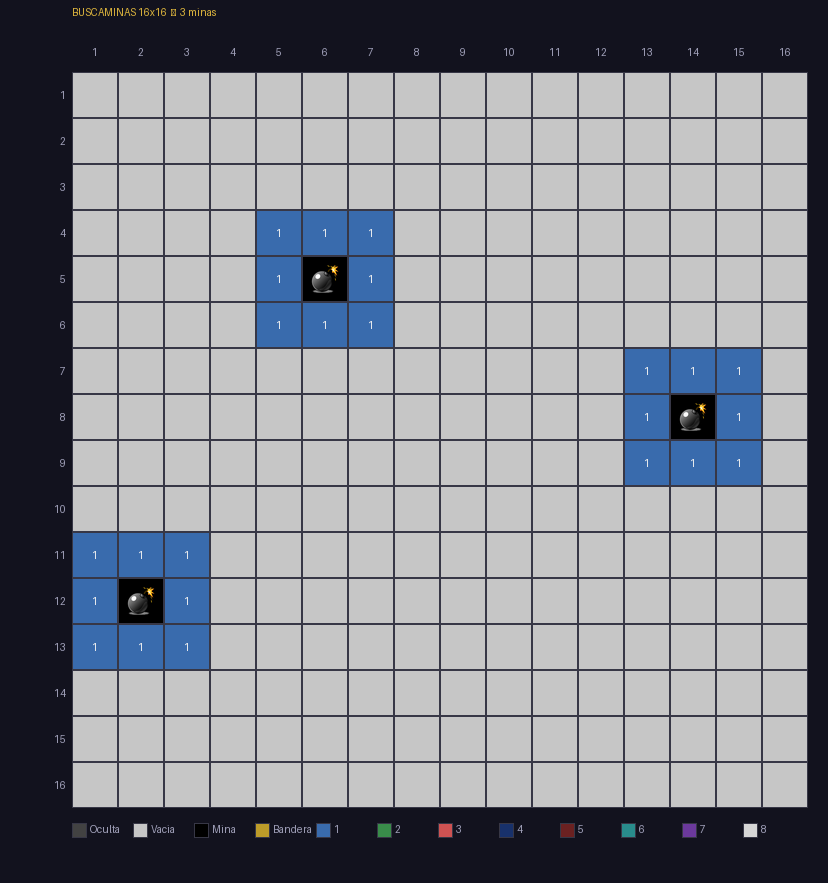

Archivo guardado: buscaminas.mas


In [ ]:
import os

directorio_salida = "/content/"
ruta_png = os.path.join(directorio_salida, "tablero_buscaminas.png")
os.makedirs(directorio_salida, exist_ok=True)

if __name__ == "__main__":
    # Pedir numero de minas
    while True:
        try:
            minas_input = int(input(f"Ingresa el numero de minas (1-{FILAS*COLUMNAS-1}): "))
            if 1 <= minas_input <= FILAS * COLUMNAS - 1:
                MINAS = minas_input
                break
            print(f"  Debe ser entre 1 y {FILAS*COLUMNAS-1}.")
        except ValueError:
            print("  Ingresa un numero entero valido.")

    tablero = generar_tablero()
    tablero = calcular_numeros(tablero)

    guardar_imagen(tablero, ruta_png)

    lineas = generar_codigo(tablero)
    contenido = "\n".join(lineas)

    filename = "buscaminas.mas"
    with open(filename, "w", encoding="utf-8") as f:
        f.write(contenido)

    print(f"Archivo guardado: {filename}")